In [5]:
print("all ok")

all ok


In [6]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: /Users/vmaganahalli/Documents/LLMOPS


In [7]:
from research_analyst.utils.model_loader import ModelLoader

In [8]:
model_loader = ModelLoader()

{"timestamp": "2025-10-24T20:15:20.913886Z", "level": "info", "event": "Running in LOCAL mode: .env loaded"}
{"timestamp": "2025-10-24T20:15:20.914866Z", "level": "info", "event": "Loaded GROQ_API_KEY from individual env var"}
{"timestamp": "2025-10-24T20:15:20.916058Z", "level": "info", "event": "Loaded GOOGLE_API_KEY from individual env var"}
{"keys": {"GROQ_API_KEY": "gsk_Tm...", "GOOGLE_API_KEY": "AIzaSy..."}, "timestamp": "2025-10-24T20:15:20.917245Z", "level": "info", "event": "API keys loaded"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2025-10-24T20:15:20.921064Z", "level": "info", "event": "YAML config loaded"}


In [9]:
llm=model_loader.load_llm()

{"provider": "groq", "model": "openai/gpt-oss-20b", "timestamp": "2025-10-24T20:15:20.930528Z", "level": "info", "event": "Loading LLM"}


In [10]:
llm.invoke("hi").content

Retrying request to /openai/v1/chat/completions in 0.478456 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I help you today?'

In [11]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [12]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

#health

Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
        ),

Analyst(
    name="Dr. Arun Verma",
    role="Ethics Researcher",
    affiliation="WHO",
    description="Explores ethical implications of AI in diagnostics."
),
Analyst(
    name="Ms. Priya Sharma",
    role="Policy Analyst",
    affiliation="Ministry of Health",
    description="Investigates AI policy and compliance frameworks."
)

In [13]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"
    

In [14]:
Analyst(
    name="Venky Mrv",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

Analyst(name='Venky Mrv', role='genai eng', affiliation='AI Research LAB', description='I am genai developer as well as mentor')

In [15]:
analyst = Analyst(
    name="Venky Maganahalli",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor"
    )

In [16]:
analyst.name

'Venky Maganahalli'

In [17]:
analyst.role

'genai eng'

In [18]:
analyst.affiliation

'AI Research LAB'

In [19]:
print(analyst.persona)

Name: Venky Maganahalli
Role: genai eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [20]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [21]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    

In [22]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [23]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [24]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [25]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']

In [26]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}
    

In [27]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Maya Patel', role='Digital Health Policy Analyst', affiliation='World Health Organization', description='Dr. Patel specializes in evaluating the impact of telemedicine and digital health solutions on patient outcomes and health system efficiency. She focuses on policy frameworks that promote equitable access to technology, data privacy, and integration of AI tools in clinical workflows.'),
  Analyst(name='Dr. Luis Hernandez', role='Health Equity Researcher', affiliation='Centers for Disease Control and Prevention', description='Dr. Hernandez studies systemic barriers to healthcare access, with a focus on socioeconomic, racial, and geographic disparities. He develops evidence-based interventions to reduce health inequities and monitors the effectiveness of public health programs targeting underserved populations.')]}

In [28]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [29]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END


In [30]:
# def should_continue(state):
#     """ Return the next node to execute """
#     human_analyst_feedback = state.get("human_analyst_feedback",None)
#     if human_analyst_feedback:
#         return "create_analyst"

In [31]:
from IPython.display import Image, display

## First Workflow

In [32]:
builder = StateGraph(GenerateAnalystsState)

In [33]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [34]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [35]:
memory = MemorySaver()

In [36]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

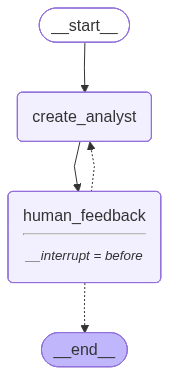

In [37]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [38]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [39]:
max_analysts = 4

In [40]:
thread =  {"configurable":{"thread_id":1}}

In [41]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  
            
        

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Maya Patel
Affiliation: TechScale Analytics
Role: Performance Engineer
Description: Dr. Patel specializes in evaluating the scalability and performance of agent frameworks, focusing on throughput, latency, and distributed execution capabilities of Langgraph.
--------------------------------------------------
Name: Alex Chen
Affiliation: OpenSource Labs
Role: Integration Specialist
Description: Alex examines the developer experience, API design, SDK quality, and ease of integrating Langgraph with existing systems and third‑party services.
--------------------------------------------------
Name: Priya Nair
Affiliation: Langgraph Foundation
Role: Community Manager
Description: Priya assesses the health of the Langgraph ecosystem, community contributions, documentation quality, and the framework’s adoption trajectory.
--------------------------------------------------
Name: Dr. Luis Gomez
Affiliation: SecureAI Inc.
Role: Security Analyst
Description: Dr. Gomez focuses on security

In [42]:
state = graph.get_state(thread)

In [43]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Maya Patel', role='Performance Engineer', affiliation='TechScale Analytics', description='Dr. Patel specializes in evaluating the scalability and performance of agent frameworks, focusing on throughput, latency, and distributed execution capabilities of Langgraph.'), Analyst(name='Alex Chen', role='Integration Specialist', affiliation='OpenSource Labs', description='Alex examines the developer experience, API design, SDK quality, and ease of integrating Langgraph with existing systems and third‑party services.'), Analyst(name='Priya Nair', role='Community Manager', affiliation='Langgraph Foundation', description='Priya assesses the health of the Langgraph ecosystem, community contributions, documentation quality, and the framework’s adoption trajectory.'), Analyst(name='Dr. Luis Gomez', role='Security Analyst', affiliation='SecureAI Inc.', descrip

In [44]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Maya Patel', role='Performance Engineer', affiliation='TechScale Analytics', description='Dr. Patel specializes in evaluating the scalability and performance of agent frameworks, focusing on throughput, latency, and distributed execution capabilities of Langgraph.'),
  Analyst(name='Alex Chen', role='Integration Specialist', affiliation='OpenSource Labs', description='Alex examines the developer experience, API design, SDK quality, and ease of integrating Langgraph with existing systems and third‑party services.'),
  Analyst(name='Priya Nair', role='Community Manager', affiliation='Langgraph Foundation', description='Priya assesses the health of the Langgraph ecosystem, community contributions, documentation quality, and the framework’s adoption trajectory.'),
  Analyst(name='Dr. Luis Gomez', role='Security Analyst', affiliation='SecureAI Inc.', description='Dr. Gom

In [45]:
state.next

('human_feedback',)

In [46]:
# memory.storage

In [47]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f0b1163-dad8-67a6-bfff-f1301185c6b2': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2025-10-24T20:15:53.066478+00:00\xa2id\xd9$1f0b1163-dad8-67a6-bfff-f1301185c6b2\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.3928924287497646\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f0b1163-dada-65ce-8000-ce67003b7de3': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2025-10-24T20:15:53.067247+00:00\xa2id\xd9$1f0b1163-dada-65ce-8000-ce67003b7de3\xb0channel_versions\x84\xa9__start__\xd9200000000000000000000000000000002.0.573104828810389\xa5topic\xd9200000000000000000000000000000002.0.573104828810389\xacmax_analysts\xd9200000000000000000000000000000002.0.573104828810389\xb8branch:to:create_analyst\xd9200000000000000000000000000000002.0.573104828810389\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start__\xd9300

In [48]:
# import msgpack

# for thread_id, ns_dict in memory.storage.items():
#     print(f"\n Thread ID: {thread_id}")
    
#     # ns_dict = defaultdict(dict, {'': {...}})
#     for ns, ckpts in ns_dict.items():
#         print(f"  Namespace: '{ns}'")
        
#         # ckpts = dict of {checkpoint_id: (packed_values, packed_metadata, parent_id)}
#         for ckpt_id, (packed_values, packed_metadata, parent_id) in ckpts.items():
#             print(f"    Checkpoint ID: {ckpt_id}")
            
#             # Decode msgpack binary
#             values = msgpack.unpackb(packed_values[1], raw=False)
#             meta = msgpack.unpackb(packed_metadata[1], raw=False)
            
#             print(f"    Values keys: {list(values.keys())}")
#             print(f"    Parent ID: {parent_id}")
#             print(f"    Metadata: {meta}")
#             print("-" * 80)


In [49]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b1163-e071-6b7c-8001-7ddfb6d87a3d'}}

In [50]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b1163-e1eb-652a-8002-a07a2326d1a2'}}

In [51]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Maya Patel
Affiliation: TechScale Analytics
Role: Performance Engineer
Description: Dr. Patel specializes in evaluating the scalability and performance of agent frameworks, focusing on throughput, latency, and distributed execution capabilities of Langgraph.
--------------------------------------------------
Name: Alex Chen
Affiliation: OpenSource Labs
Role: Integration Specialist
Description: Alex examines the developer experience, API design, SDK quality, and ease of integrating Langgraph with existing systems and third‑party services.
--------------------------------------------------
Name: Priya Nair
Affiliation: Langgraph Foundation
Role: Community Manager
Description: Priya assesses the health of the Langgraph ecosystem, community contributions, documentation quality, and the framework’s adoption trajectory.
--------------------------------------------------
Name: Dr. Luis Gomez
Affiliation: SecureAI Inc.
Role: Security Analyst
Description: Dr. Gomez focuses on security

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Maya Patel
Affiliation: TechCrunch
Role: Startup Advisor
Description: Maya brings a deep understanding of early-stage scaling, product-market fit, and cost-effective AI adoption. She evaluates how Langgraph can accelerate innovation while keeping budgets lean.
--------------------------------------------------
Name: Dr. Li Wei
Affiliation: Gartner
Role: Enterprise AI Strategist
Description: Dr. Li specializes in regulatory compliance, data governance, and seamless integration with legacy systems. She assesses Langgraph’s fit for large enterprises needing robust, compliant AI solutions.
--------------------------------------------------
Name: Alex Kim
Affiliation: NVIDIA
Role: AI Systems Engineer
Description: Alex focuses on performance benchmarks, distributed computing, and resource optimization. He examines how Langgraph’s architecture can deliver high throughput and low latency at scale.
--------------------------------------------------
Name: Sarah O'Connor
Affiliation: GitHub

In [52]:
state = graph.get_state(thread)

In [53]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Maya Patel', role='Startup Advisor', affiliation='TechCrunch', description='Maya brings a deep understanding of early-stage scaling, product-market fit, and cost-effective AI adoption. She evaluates how Langgraph can accelerate innovation while keeping budgets lean.'), Analyst(name='Dr. Li Wei', role='Enterprise AI Strategist', affiliation='Gartner', description='Dr. Li specializes in regulatory compliance, data governance, and seamless integration with legacy systems. She assesses Langgraph’s fit for large enterprises needing robust, compliant AI solutions.'), Analyst(name='Alex Kim', role='AI Systems Engineer', affiliation='NVIDIA', description='Alex focuses on performance benchmarks, distributed computing, and resource optimization

In [54]:
state.next

('human_feedback',)

In [55]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Maya Patel', role='Startup Advisor', affiliation='TechCrunch', description='Maya brings a deep understanding of early-stage scaling, product-market fit, and cost-effective AI adoption. She evaluates how Langgraph can accelerate innovation while keeping budgets lean.'),
  Analyst(name='Dr. Li Wei', role='Enterprise AI Strategist', affiliation='Gartner', description='Dr. Li specializes in regulatory compliance, data governance, and seamless integration with legacy systems. She assesses Langgraph’s fit for large enterprises needing robust, compliant AI solutions.'),
  Analyst(name='Alex Kim', role='AI Systems Engineer', affiliation='NVIDIA', description='Alex focuses on performance benchmarks, distributed computing, and resource optimization. He examines 

In [56]:
# import msgpack

# def get_all_checkpoints(memory, thread_id="1"):
#     """Return all checkpoints in chronological order for a thread."""
#     checkpoints = []
#     ns_dict = memory.storage.get(thread_id, {})
#     if "" not in ns_dict:
#         return []

#     for ckpt_id, (packed_values, packed_meta, parent_id) in ns_dict[""].items():
#         values = msgpack.unpackb(packed_values[1], raw=False)
#         meta = msgpack.unpackb(packed_meta[1], raw=False)
#         checkpoints.append({
#             "id": ckpt_id,
#             "parent": parent_id,
#             "topic": values.get("topic"),
#             "feedback": values.get("human_analyst_feedback"),
#             "analyst_count": len(values.get("analysts", [])),
#             "analysts": [a.model_dump() for a in values.get("analysts", [])],
#             "step": meta.get("step"),
#             "created_at": values.get("ts", None)
#         })
#     return checkpoints

# # Fetch all
# history = get_all_checkpoints(memory)

# # Sort by step (to get chronological order)
# history = sorted(history, key=lambda x: (x["step"] or 0))

# # Display neatly
# for h in history:
#     print(f"\nSTEP {h['step']} | CHECKPOINT {h['id']}")
#     print(f"Parent: {h['parent']}")
#     print(f"Topic: {h['topic']}")
#     print(f"Feedback: {h['feedback']}")
#     print(f"Analysts generated: {h['analyst_count']}")
#     print("-"*100)


In [57]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [58]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [59]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b1163-e90a-6d38-8006-b0d2708c531b'}}

In [60]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)


()


In [61]:
analysts = final_state.values.get('analysts')

In [62]:
analysts

[Analyst(name='Maya Patel', role='Startup Advisor', affiliation='TechCrunch', description='Maya brings a deep understanding of early-stage scaling, product-market fit, and cost-effective AI adoption. She evaluates how Langgraph can accelerate innovation while keeping budgets lean.'),
 Analyst(name='Dr. Li Wei', role='Enterprise AI Strategist', affiliation='Gartner', description='Dr. Li specializes in regulatory compliance, data governance, and seamless integration with legacy systems. She assesses Langgraph’s fit for large enterprises needing robust, compliant AI solutions.'),
 Analyst(name='Alex Kim', role='AI Systems Engineer', affiliation='NVIDIA', description='Alex focuses on performance benchmarks, distributed computing, and resource optimization. He examines how Langgraph’s architecture can deliver high throughput and low latency at scale.'),
 Analyst(name="Sarah O'Connor", role='Open Source Advocate', affiliation='GitHub', description='Sarah champions tooling, community, and eas

In [63]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Maya Patel
Affiliation: TechCrunch
Role: Startup Advisor
Description: Maya brings a deep understanding of early-stage scaling, product-market fit, and cost-effective AI adoption. She evaluates how Langgraph can accelerate innovation while keeping budgets lean.
--------------------------------------------------
Name: Dr. Li Wei
Affiliation: Gartner
Role: Enterprise AI Strategist
Description: Dr. Li specializes in regulatory compliance, data governance, and seamless integration with legacy systems. She assesses Langgraph’s fit for large enterprises needing robust, compliant AI solutions.
--------------------------------------------------
Name: Alex Kim
Affiliation: NVIDIA
Role: AI Systems Engineer
Description: Alex focuses on performance benchmarks, distributed computing, and resource optimization. He examines how Langgraph’s architecture can deliver high throughput and low latency at scale.
--------------------------------------------------
Name: Sarah O'Connor
Affiliation: GitHub

In [64]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


## Second Workflow

In [65]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [66]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [67]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

/var/folders/9b/m8m9lcyd4vx1v7qg6530ht8h0000gn/T/ipykernel_2045/1029971610.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)


In [68]:
tavily_search.invoke("langgraph")

[{'title': 'What is LangGraph? - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
  'content': 'geeksforgeeks\n\n# What is LangGraph?\n\nLangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions.',
  'score': 0.9407083},
 {'title': 'LangGraph overview - Docs by LangChain',
  'url': 'https://docs.langchain.com/oss/python/langgraph/overview',
  'content': "Trusted by companies shaping the future of agents— including Klarna, Replit, Elastic, and more— LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents.LangGraph is very low-level, and focused entirely on agent orchestration. Before using LangGraph, we recommend you familia

In [69]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="LangGraph").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 

In [70]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [71]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [72]:
print(analyst.persona)

Name: Sarah O'Connor
Role: Open Source Advocate
Affiliation: GitHub
Description: Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.



In [73]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Sarah O\'Connor\nRole: Open Source Advocate\nAffiliation: GitHub\nDescription: Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your res

In [74]:
'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided to you.'

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you

In [75]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [76]:
analyst

Analyst(name="Sarah O'Connor", role='Open Source Advocate', affiliation='GitHub', description='Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.')

In [77]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [78]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [79]:
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name="Sarah O'Connor", role='Open Source Advocate', affiliation='GitHub', description='Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.'),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [80]:
result = generation_question(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [81]:
result

{'messages': [AIMessage(content='Hi there! I’m **Alex Rivera**, a tech analyst who loves digging into the nuts and bolts of open‑source ecosystems. I’m excited to chat with Sarah O’Connor about how Langgraph is reshaping developer workflows at GitHub. \n\n**Sarah,** could you start by sharing a concrete example of a team that used Langgraph’s plugin ecosystem to solve a real‑world problem—something that might surprise people who think of Langgraph as just another AI tool?', additional_kwargs={'reasoning_content': 'We need to respond as an analyst interviewing Sarah O\'Connor, an open source advocate at GitHub. The user says "hi do the proper search according to the experties". That seems like a request to do a proper search. But the instructions say we are to interview the expert. So we should respond as the analyst, introduce ourselves, ask a question. The user didn\'t ask a question, but we can proceed with the interview. The user might want us to do a search? But the instructions sa

In [82]:
print(result["messages"][0].content)

Hi there! I’m **Alex Rivera**, a tech analyst who loves digging into the nuts and bolts of open‑source ecosystems. I’m excited to chat with Sarah O’Connor about how Langgraph is reshaping developer workflows at GitHub. 

**Sarah,** could you start by sharing a concrete example of a team that used Langgraph’s plugin ecosystem to solve a real‑world problem—something that might surprise people who think of Langgraph as just another AI tool?


In [83]:
from langchain_core.messages import get_buffer_string

In [84]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [85]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [86]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [87]:
result = search_web(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [88]:
print(result["context"][0])

<Document href="https://medium.com/@kajal.verma/langgraph-building-smarter-ai-agents-with-graph-based-workflows-b520eadfc582"/>
LangGraph is a framework built to help developers create AI workflows using graph-based structures. The idea is simple — just like flowcharts or decision trees, you can design workflows as graphs, where each node represents a task or decision, and the edges define the flow of data between them. This approach makes it easier to understand and manage complex AI logic. [...] If you’re looking to create advanced AI systems that can evolve and scale with your business, LangGraph is the framework you need. From visualizing AI workflows to orchestrating AI agents and automating tasks, LangGraph gives you the tools to build the next generation of intelligent applications.

AI

Langgraph

Landgraph Ai

Ai Agent

## Written by Digital Transformation

0 followers

·1 following [...] Sitemap

Open in app

Sign in

Sign in

# LangGraph: Building Smarter AI Agents with Grap

In [89]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 
    

In [90]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [91]:
result = search_wikipedia(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph framework definition and its role in business innovation and digital transformation'


In [92]:
search_docs = WikipediaLoader(query='Langgraph framework benefits',load_all_available_meta=True).load()

In [93]:
search_docs

[]

In [94]:
result

{'context': ['']}

In [95]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [96]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}
    

how many analyst we were doing to be create:
4

max_trun:2

means if atleast 2 expert are giving ans then we can save the result.

In [97]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [98]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [99]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [100]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}


In [101]:
interview_builder = StateGraph(InterviewState)

In [102]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [103]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [104]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")


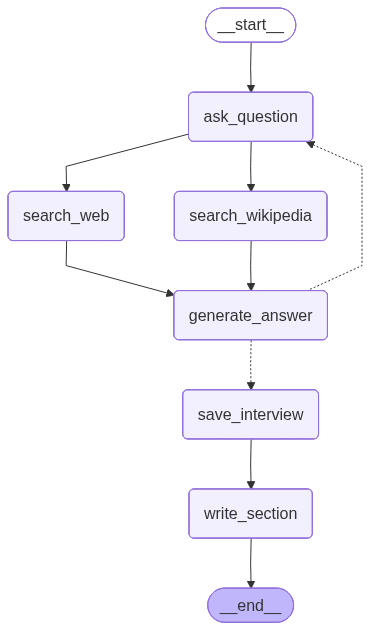

In [105]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [106]:
analyst

Analyst(name="Sarah O'Connor", role='Open Source Advocate', affiliation='GitHub', description='Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.')

In [107]:
analyst.persona

"Name: Sarah O'Connor\nRole: Open Source Advocate\nAffiliation: GitHub\nDescription: Sarah champions tooling, community, and ease of use. She explores Langgraph’s developer experience, plugin ecosystem, and how it empowers teams to iterate quickly.\n"

In [113]:
thread = {"configurable": {"thread_id": "1"}}

In [114]:
from IPython.display import Markdown

In [110]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [116]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph best practices for beginners plugin configuration pitfalls conversation flow debugging'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 25.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 24.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [118]:
Markdown(interview['sections'][0])

## Empowering Rapid Agent Development with LangGraph’s Tooling and Community

### Summary

LangGraph has evolved into a comprehensive platform that lowers the barrier to building, deploying, and iterating on complex, stateful agents. Its developer experience is anchored in a visual studio, a rich plugin ecosystem, and tight integration with LangChain and LangSmith, enabling teams to prototype, debug, and scale with minimal friction.

1. **Visual Prototyping & Deployment** – LangGraph Studio offers a drag‑and‑drop interface for graph architecture visualization, interactive testing, and time‑travel debugging. Teams can share agents across repositories and iterate quickly without writing boilerplate code.  
2. **Extensible Plugin Ecosystem** – Plugins such as `langgraph-reflection` provide self‑improving agents that critique and refine their own outputs, while `langgraph-bigtool` manages large tool libraries. These plug‑ins are open‑source and can be forked or extended, fostering a vibrant community.  
3. **Seamless LangChain Integration** – LangGraph can be used standalone or as a low‑level orchestration layer beneath LangChain products. Pre‑built templates (ReAct, memory, retrieval) and a structured academy course lower onboarding time.  
4. **Robust State Management** – Automatic checkpointing, typed state dictionaries, and reducer functions keep conversation history and context consistent across multi‑agent workflows. This persistence is critical for production systems like Exa’s research agent, which processes hundreds of queries per day with sub‑minute latency.  
5. **Performance Optimizations** – Streaming node outputs (`.astream()`), token‑level streaming, and configurable recursion limits reduce perceived latency and memory overhead. Memory‑compression strategies keep long conversations efficient without sacrificing context.  
6. **Observability & Debugging** – LangSmith integration provides tracing, evaluation, and debugging dashboards. Time‑travel debugging lets developers step back through state changes, making it easier to pinpoint failures in complex agent chains.  

These features collectively create a low‑friction loop: developers can prototype in Studio, iterate with live debugging, deploy via the purpose‑built platform, and monitor with LangSmith—all while leveraging community‑built plugins and templates. The result is a rapid, collaborative workflow that scales from prototypes to production‑grade multi‑agent systems.

**Sources used**: [1], [2], [3], [4], [5], [6], [7], [8], [9], [10].

### Sources  
[1] https://github.com/von-development/awesome-LangGraph  
[2] https://github.com/langchain-ai/langgraph  
[3] https://blog.langchain.com/exa/  
[4] https://medium.com/@garima_yadav/real-world-applications-and-case-studies-with-langgraph-from-theory-to-practice-7a6ffd2e8e1b  
[5] https://sumanmichael.github.io/langgraph-cheatsheet/cheatsheet/performance-optimization/  
[6] https://latenode.com/blog/langgraph-tutorial-complete-beginners-guide-to-getting-started  
[7] https://gist.github.com/razhangwei/631a799e6bd69b26ce9c118c624cd80d  
[8] https://www.analyticsvidhya.com/blog/2025/05/langgraph-tutorial-for-beginners/  
[9] https://medium.com/@ashutoshsharmaengg/getting-started-with-langgraph-a-beginners-guide-to-building-intelligent-workflows-67eeee0899d0  
[10] https://dev.to/damilola_oyedunmade/a-beginners-guide-to-getting-started-in-agent-state-in-langgraph-3bkj

## Third Workflow

In [119]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

In [120]:
from langgraph.types import Send

In [121]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [122]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [123]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [124]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [125]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [126]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [127]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [128]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

In [129]:
memory = MemorySaver()

In [130]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

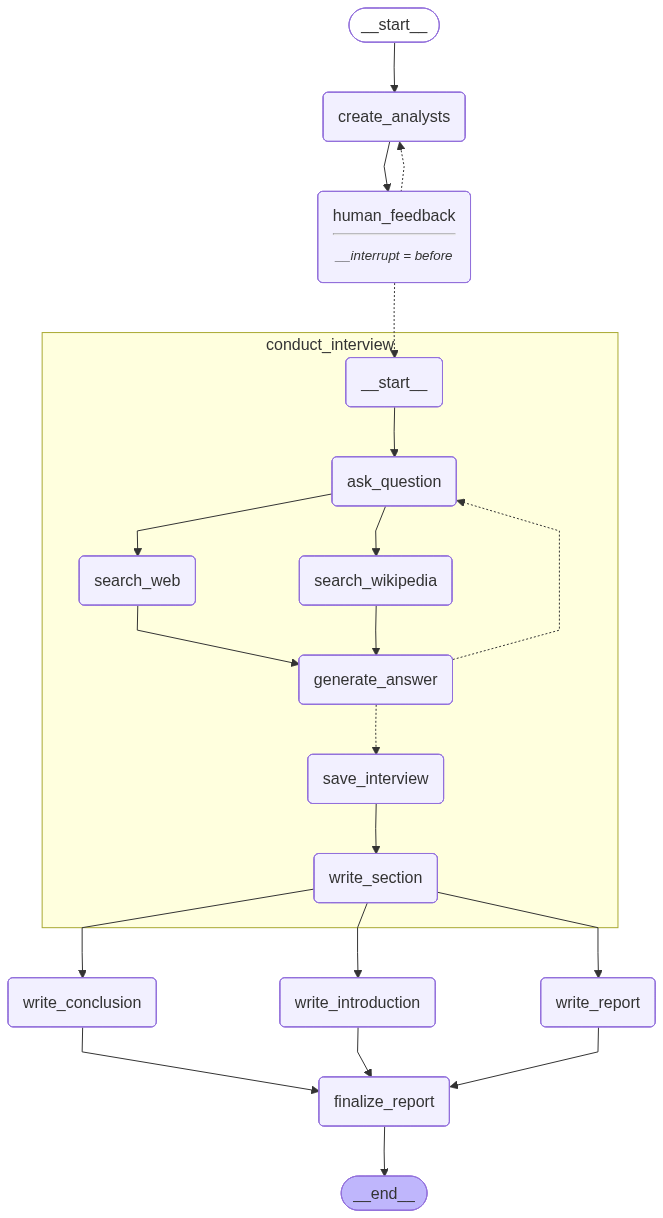

In [131]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [132]:
max_analysts = 3

In [133]:
topic = "How can generative AI help us to play cricket?"

In [134]:
thread = {"configurable": {"thread_id": "1"}}

In [136]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Aisha Patel
Affiliation: University of Cambridge, Sports Analytics Lab
Role: Player Development Analyst
Description: Specializes in using generative AI to model player biomechanics, simulate skill acquisition pathways, and provide personalized coaching feedback for cricketers at all levels.
--------------------------------------------------
Name: Prof. Miguel Santos
Affiliation: MIT Media Lab, AI Strategy Group
Role: Tactical Decision Analyst
Description: Focuses on real-time match simulation, predictive modeling of opposition tactics, and AI-driven decision support for captains and coaches.
--------------------------------------------------
Name: Lena Kim
Affiliation: Fan Experience Inc., Immersive Media Division
Role: Fan Engagement Analyst
Description: Leverages generative AI to create dynamic narratives, personalized commentary, and interactive virtual experiences that deepen fan connection to cricket.
--------------------------------------------------


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Aisha Patel
Affiliation: University of Cambridge, Sports Analytics Lab
Role: Player Development Analyst
Description: Specializes in using generative AI to model player biomechanics, simulate skill acquisition pathways, and provide personalized coaching feedback for cricketers at all levels.
--------------------------------------------------
Name: Prof. Miguel Santos
Affiliation: MIT Media Lab, AI Strategy Group
Role: Tactical Decision Analyst
Description: Focuses on real-time match simulation, predictive modeling of opposition tactics, and AI-driven decision support for captains and coaches.
--------------------------------------------------
Name: Lena Kim
Affiliation: Fan Experience Inc., Immersive Media Division
Role: Fan Engagement Analyst
Description: Leverages generative AI to create dynamic narratives, personalized commentary, and interactive virtual experiences that deepen fan connection to cricket.
--------------------------------------------------


In [137]:
graph.update_state(thread, {"human_analyst_feedback":"along with the generative ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b1187-5d8e-6be6-8005-39db34186ada'}}

In [138]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Aisha Patel
Affiliation: University of Cambridge, Sports Analytics Lab
Role: Player Development Analyst
Description: Specializes in using generative AI to model player biomechanics, simulate skill acquisition pathways, and provide personalized coaching feedback for cricketers at all levels.
--------------------------------------------------
Name: Prof. Miguel Santos
Affiliation: MIT Media Lab, AI Strategy Group
Role: Tactical Decision Analyst
Description: Focuses on real-time match simulation, predictive modeling of opposition tactics, and AI-driven decision support for captains and coaches.
--------------------------------------------------
Name: Lena Kim
Affiliation: Fan Experience Inc., Immersive Media Division
Role: Fan Engagement Analyst
Description: Leverages generative AI to create dynamic narratives, personalized commentary, and interactive virtual experiences that deepen fan connection to cricket.
--------------------------------------------------


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Arjun Mehta
Affiliation: Indian Institute of Technology, Delhi
Role: Sports Performance Analyst
Description: Specializes in applying machine learning to player biomechanics, strategy optimization, and predictive modeling for cricket. Focuses on how generative AI can enhance training regimens and in-game decision making.
--------------------------------------------------
Name: Ms. Priya Nair
Affiliation: SportsTech Innovations Pvt. Ltd.
Role: Fan Engagement Strategist
Description: Expert in AI-driven content creation, personalized fan experiences, and social media analytics. Explores how generative AI can transform marketing, commentary, and immersive fan interactions.
--------------------------------------------------
Name: Prof. Sanjay Rao
Affiliation: University of Hyderabad
Role: Cricket Historian & Futurist
Description: Studies the evolution of cricket and uses AI to forecast team dynamics, talent pipelines, and the future trajectory of the Indian national team.
---------

In [141]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b118a-5030-6208-800a-175d8739f181'}}

In [142]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [146]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


--Node--
conduct_interview


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


--Node--
write_conclusion
--Node--
write_introduction


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


--Node--
write_report
--Node--
finalize_report


In [147]:
from IPython.display import Markdown

In [148]:
final_state = graph.get_state(thread)

In [149]:
report = final_state.values.get('final_report')

In [150]:
Markdown(report)

# How Generative AI is Scoring Big in Cricket

## Introduction

Generative AI is redefining every facet of modern cricket—from biomechanical training and in‑match tactics to immersive fan experiences and national team strategy. In the first section, we explore how AI’s precision analytics and real‑time dashboards sharpen player performance and decision‑making. The second part showcases AI‑driven match simulations, virtual coaching, and personalized commentary that transform broadcasting and fan engagement. Finally, we examine India’s AI‑powered ecosystem, highlighting VR coaching, injury prediction, and talent‑identification tools that are reshaping the national squad’s future. Together, these chapters illustrate a future where data, imagination, and sport converge to elevate cricket to unprecedented heights.

---



Generative AI is redefining cricket across every layer of the sport, from the micro‑level of individual biomechanics to the macro‑level of global fan experience. At its core, AI delivers unprecedented precision in training, strategy, and engagement, turning data into actionable insight and entertainment.

**Biomechanical mastery and injury prevention**  
Wearable sensors paired with machine‑learning models now monitor fatigue and workload in real time, allowing coaches to prescribe optimal rest and reduce injury risk—an objective that once relied on subjective judgment alone [2]. Advanced vision systems analyse video to predict deceptive bowler movements with up to 70 % accuracy, giving batsmen a predictive edge that rivals human intuition [5]. These same models flag biomechanical hotspots before injury manifests, extending player careers and keeping star talent on the field [2].

**Strategic depth through simulation and dashboards**  
Generative AI can generate thousands of “what‑if” match scenarios, enabling teams to rehearse rare situations and refine tactics without costly practice matches [6, 7]. Real‑time dashboards that display metrics such as bowler fatigue, batsman reaction time, and fielding efficiency empower captains to adjust tactics on the fly, a capability already adopted by national sides [1, 4]. AI‑enhanced decision‑review systems, integrating Hawk‑Eye and UltraEdge data, reduce human error and increase trust in on‑field calls [1, 3].

**Talent pipeline and inclusive coaching**  
Virtual‑reality platforms combined with AI analytics deliver personalised coaching even for players with disabilities, expanding the talent pool and breaking traditional barriers [1]. Machine‑learning models sift through vast datasets—performance stats, biometric readings, and social‑media sentiment—to identify emerging prospects and map their developmental trajectories, ensuring a steady flow of ready‑to‑play talent for national squads [6]. Emerging tools also assess mental resilience, integrating cognitive metrics into training programmes to build psychological readiness [3].

**Fan engagement and commercial value**  
Stadiums can now deliver immersive, personalised experiences—AR overlays of player statistics, AI‑generated match summaries, and interactive commentary—directly to spectators, boosting attendance and revenue [8]. In broadcast, generative commentary engines weave live statistics, historical comparisons, and narrative flair into the feed, creating a richer viewing experience that can be tailored to individual fan preferences [9]. Broadcasters can offer “choose‑your‑own‑commentary” streams that adapt tone to viewer engagement, while social‑media analytics surface micro‑moments that resonate with niche audiences, driving higher interaction rates and opening new revenue streams through dynamic ad placements and data‑driven fan loyalty programmes [1, 3].

**A holistic, data‑driven ecosystem**  
Collectively, these innovations illustrate a future where AI not only sharpens player performance but also enriches strategic depth and fan interaction. Cricket teams are moving from intuition‑based decision making to algorithmic certainty, while fans experience the sport in more immersive, personalised ways. As AI becomes a foundational requirement rather than a competitive advantage, the sport will see more resilient, adaptable, and strategically superior teams on the global stage.

## Sources  

1. https://wireunwired.com/the-future-of-cricket-training-is-ai-powered/  
2. https://www.ijfmr.com/papers/2024/4/25324.pdf  
3. https://timespro.com/executive-education/iit-delhi-certificate-programme-in-generative-ai  
4. https://www.linkedin.com/pulse/how-ai-transforming-cricket-future-performance-vaibhav-kulshrestha-eaf7c/  
5. https://www.sciencedirect.com/science/article/pii/S2307187725000070  
6. https://webosmotic.com/blog/ai-in-cricket/  
7. https://github.com/resources/articles/what-are-generative-ai-models  
8. https://www.akaike.ai/resources/how-can-generative-ai-and-computer-vision-improve-stadium-attendance-in-the-icc-world-cup-by-blurring-the-lines-between-digital-and-offline-experiences  
9. https://medium.com/@jeyadev_needhi/ipl-2-0-the-ai-version-transforming-cricket-with-artificial-intelligence-2eec10f1c627  
10. https://arxiv.org/pdf/2410.01307  
11. https://xbeekon.com/the-role-of-ai-in-cricket-revolutionizing-the-game  
12. https://medium.com/@jeyadev_needhi/the-intersection-of-ai-and-cricket-revolutionizing-the-game-with-data-analysis-9920e59c13e6  
13. https://www.analyticsinsight.net/artificial-intelligence/chatipl-the-ai-revolution-in-cricket-analytics  
14. https://theword360.com/2025/06/09/how-artificial-intelligence-is-transforming-cricket-training/  
15. https://americaspg.com/article/download/3818  
16. https://journalwjarr.com/sites/default/files/fulltext_pdf/WJARR-2025-0379.pdf  
17. https://pmc.ncbi.nlm.nih.gov/articles/PMC11592714/  
18. https://numpy.org/case-studies/cricket-analytics/  
19. https://blog.hack2skill.com/case-study-parivartan-level-up-your-cricket-with-ai-and-inclusivity  
20. https://www.travancoreanalytics.com/case-study/ai-based-cricket-coaching-platform/  
21. https://www.ijraset.com/research-paper/excellence-in-cricket-leveraging-ai-ml-and-automation  
22. https://richestsoft.com/blog/how-can-ai-be-used-in-cricket/

---

## Conclusion  

Generative AI is redefining cricket across every tier—from individualized biomechanical coaching and real‑time tactical dashboards to immersive fan experiences and AI‑driven talent pipelines. In training, wearable sensors and predictive models cut injury risk while tailoring workloads, while virtual coaching and “what‑if” simulations sharpen decision‑making. Strategically, AI dashboards and generative commentary engines give captains and broadcasters a data‑rich edge, and advanced injury‑prediction models extend player longevity. For India, AI‑powered scouting, inclusive VR training, and mental‑resilience analytics are building a resilient, analytically‑driven squad. Together, these innovations position cricket at the forefront of sports technology, promising smarter play, richer engagement, and a sustainable competitive future.